In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model

In [3]:
df=pd.read_csv("Loan-Eligibility.csv")
df

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,Male,Yes,2,Graduate,No,2947,1603.0,10,360,1,Urban,N
610,525,Male,No,0,Graduate,No,4680,2087.0,15,360,1,Semiurban,N
611,551,Male,Yes,2,Graduate,Yes,6633,0.0,25,360,0,Rural,N
612,552,Male,Yes,1,Not Graduate,No,2492,2375.0,30,360,1,Rural,Y


In [4]:
from sklearn.preprocessing import LabelEncoder
dfle=df #dataframe for label encoding
dfle.Self_Employed= LabelEncoder().fit_transform(dfle.Self_Employed)
dfle

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,0,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,0,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,0,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,1,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,0,5468,1032.0,26,360,1,Semiurban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,Male,Yes,2,Graduate,0,2947,1603.0,10,360,1,Urban,N
610,525,Male,No,0,Graduate,0,4680,2087.0,15,360,1,Semiurban,N
611,551,Male,Yes,2,Graduate,1,6633,0.0,25,360,0,Rural,N
612,552,Male,Yes,1,Not Graduate,0,2492,2375.0,30,360,1,Rural,Y


In [5]:
dfle.Loan_Status= LabelEncoder().fit_transform(dfle.Loan_Status)
dfle

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,0,2378,0.0,9,360,1,Urban,0
1,15,Male,Yes,2,Graduate,0,1299,1086.0,17,120,1,Urban,1
2,95,Male,No,0,Not Graduate,0,3620,0.0,25,120,1,Semiurban,1
3,134,Male,Yes,0,Graduate,1,3459,0.0,25,120,1,Semiurban,1
4,556,Male,Yes,1,Graduate,0,5468,1032.0,26,360,1,Semiurban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,Male,Yes,2,Graduate,0,2947,1603.0,10,360,1,Urban,0
610,525,Male,No,0,Graduate,0,4680,2087.0,15,360,1,Semiurban,0
611,551,Male,Yes,2,Graduate,1,6633,0.0,25,360,0,Rural,0
612,552,Male,Yes,1,Not Graduate,0,2492,2375.0,30,360,1,Rural,1


In [6]:
df

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,0,2378,0.0,9,360,1,Urban,0
1,15,Male,Yes,2,Graduate,0,1299,1086.0,17,120,1,Urban,1
2,95,Male,No,0,Not Graduate,0,3620,0.0,25,120,1,Semiurban,1
3,134,Male,Yes,0,Graduate,1,3459,0.0,25,120,1,Semiurban,1
4,556,Male,Yes,1,Graduate,0,5468,1032.0,26,360,1,Semiurban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,Male,Yes,2,Graduate,0,2947,1603.0,10,360,1,Urban,0
610,525,Male,No,0,Graduate,0,4680,2087.0,15,360,1,Semiurban,0
611,551,Male,Yes,2,Graduate,1,6633,0.0,25,360,0,Rural,0
612,552,Male,Yes,1,Not Graduate,0,2492,2375.0,30,360,1,Rural,1


In [7]:
df["Total-income"]=df["Applicant_Income"]+df["Coapplicant_Income"]
df

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total-income
0,569,Female,No,0,Graduate,0,2378,0.0,9,360,1,Urban,0,2378.0
1,15,Male,Yes,2,Graduate,0,1299,1086.0,17,120,1,Urban,1,2385.0
2,95,Male,No,0,Not Graduate,0,3620,0.0,25,120,1,Semiurban,1,3620.0
3,134,Male,Yes,0,Graduate,1,3459,0.0,25,120,1,Semiurban,1,3459.0
4,556,Male,Yes,1,Graduate,0,5468,1032.0,26,360,1,Semiurban,1,6500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,Male,Yes,2,Graduate,0,2947,1603.0,10,360,1,Urban,0,4550.0
610,525,Male,No,0,Graduate,0,4680,2087.0,15,360,1,Semiurban,0,6767.0
611,551,Male,Yes,2,Graduate,1,6633,0.0,25,360,0,Rural,0,6633.0
612,552,Male,Yes,1,Not Graduate,0,2492,2375.0,30,360,1,Rural,1,4867.0


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df[['Self_Employed','Total-income','Loan_Amount','Loan_Amount_Term','Credit_History']],df.Loan_Status,test_size=0.1)

In [11]:
x_train

,Self_Employed,Total-income,Loan_Amount,Loan_Amount_Term,Credit_History
19,0,3988.0,50,240,1
43,0,2213.0,66,360,1
561,0,10173.0,296,360,1
130,1,3750.0,97,360,1
396,0,7686.0,152,360,0
...,...,...,...,...,...
278,0,4531.0,124,360,1
121,0,3723.0,96,360,1
296,0,4680.0,128,360,0
435,0,10180.0,162,360,1


In [12]:
x_test

,Self_Employed,Total-income,Loan_Amount,Loan_Amount_Term,Credit_History
70,0,3858.0,76,360,1
248,0,6085.0,120,360,0
378,0,5762.0,144,360,1
597,0,13650.0,30,360,1
477,1,7978.0,184,360,1
...,...,...,...,...,...
111,0,3849.0,95,360,1
558,1,11500.0,286,360,0
582,1,15114.0,480,360,1
342,0,4666.0,135,360,1


In [13]:
y_train

19     1
43     1
561    1
130    1
396    0
      ..
278    1
121    1
296    0
435    1
97     1
Name: Loan_Status, Length: 552, dtype: int64

In [14]:
y_test

70     1
248    0
378    1
597    1
477    1
      ..
111    1
558    0
582    1
342    1
413    0
Name: Loan_Status, Length: 62, dtype: int64

In [15]:
reg1=linear_model.LogisticRegression()
reg1

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
reg1.fit(x_train,y_train)

C:\Users\STUDENT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
reg1.score(x_test,y_test)

0.8387096774193549

In [23]:
reg1.predict([[0,500,40,6,0]])

C:\Users\STUDENT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [25]:
df=df.rename(columns={'Total-income':'income'})
df

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,income
0,569,Female,No,0,Graduate,0,2378,0.0,9,360,1,Urban,0,2378.0
1,15,Male,Yes,2,Graduate,0,1299,1086.0,17,120,1,Urban,1,2385.0
2,95,Male,No,0,Not Graduate,0,3620,0.0,25,120,1,Semiurban,1,3620.0
3,134,Male,Yes,0,Graduate,1,3459,0.0,25,120,1,Semiurban,1,3459.0
4,556,Male,Yes,1,Graduate,0,5468,1032.0,26,360,1,Semiurban,1,6500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,Male,Yes,2,Graduate,0,2947,1603.0,10,360,1,Urban,0,4550.0
610,525,Male,No,0,Graduate,0,4680,2087.0,15,360,1,Semiurban,0,6767.0
611,551,Male,Yes,2,Graduate,1,6633,0.0,25,360,0,Rural,0,6633.0
612,552,Male,Yes,1,Not Graduate,0,2492,2375.0,30,360,1,Rural,1,4867.0


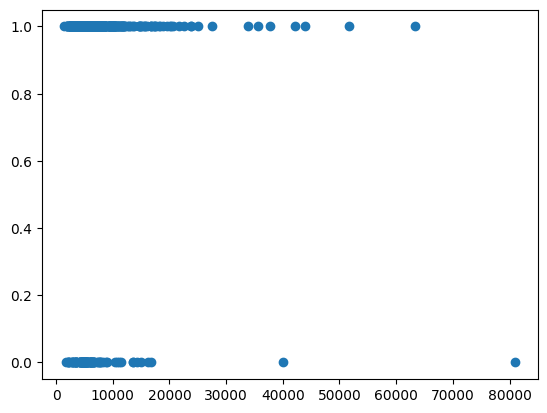

In [26]:
from sklearn.linear_model import LogisticRegression
plt.scatter(df.income,df.Credit_History)